In [1]:
# ==========================================================
# STEP 1 : Import Required Libraries
# ==========================================================

# -------------------------------
# Basic Libraries
# -------------------------------

import os
import time
import copy
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# -------------------------------
# Image Processing
# -------------------------------

from PIL import Image

# -------------------------------
# PyTorch
# -------------------------------

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

# -------------------------------
# TorchVision
# -------------------------------

from torchvision import transforms

# -------------------------------
# TIMM
# -------------------------------

import timm

# -------------------------------
# Evaluation
# -------------------------------

from sklearn.metrics import accuracy_score

print("="*60)
print("STEP 1 COMPLETED")
print("Libraries Imported Successfully")
print("="*60)

STEP 1 COMPLETED
Libraries Imported Successfully


In [2]:
# ==========================================================
# STEP 2 : Project Configuration
# ==========================================================

TRAIN_CSV = "train_metadata.csv"

VALIDATION_CSV = "validation_metadata.csv"

TEST_CSV = "test_metadata.csv"

IMAGE_FOLDER = "Segmented_Images"

IMAGE_SIZE = 224

NUM_CLASSES = 2

BATCH_SIZE = 4

LEARNING_RATE = 1e-4

NUM_EPOCHS = 15

MODEL_NAME = "coatnet_bn_0_rw_224"

BEST_MODEL_PATH = "best_model.pth"

HISTORY_PATH = "training_history.csv"

print("="*60)
print("STEP 2 COMPLETED")
print("="*60)

print("Batch Size :",BATCH_SIZE)
print("Epochs :",NUM_EPOCHS)
print("Image Size :",IMAGE_SIZE)

STEP 2 COMPLETED
Batch Size : 4
Epochs : 15
Image Size : 224


In [3]:
# ==========================================================
# STEP 3 : Device Configuration
# ==========================================================

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

print("="*60)
print("STEP 3 COMPLETED")
print("="*60)

print("Device :",device)

STEP 3 COMPLETED
Device : cpu


In [4]:
# ==========================================================
# STEP 4 : Load Metadata
# ==========================================================

train_df = pd.read_csv(TRAIN_CSV)

validation_df = pd.read_csv(VALIDATION_CSV)

test_df = pd.read_csv(TEST_CSV)

print("="*60)
print("STEP 4 COMPLETED")
print("="*60)

print("Training Images :",len(train_df))

print("Validation Images :",len(validation_df))

print("Testing Images :",len(test_df))

STEP 4 COMPLETED
Training Images : 560
Validation Images : 120
Testing Images : 120


In [5]:
# ==========================================================
# STEP 5 : Verify Metadata
# ==========================================================

display(train_df.head())

display(validation_df.head())

display(test_df.head())

,study_id,gender,age,findings,dataset,label
0,CHNCXR_0185_0.png,Male,44,normal,Shenzhen,0
1,CHNCXR_0243_0.png,Male,27,normal,Shenzhen,0
2,CHNCXR_0627_1.png,Female,26,secondary PTB in the right upper field,Shenzhen,1
3,CHNCXR_0393_1.png,Female,24,"right upper PTB, pleural adhesions in left lo...",Shenzhen,1
4,CHNCXR_0225_0.png,Male,30,normal,Shenzhen,0


,study_id,gender,age,findings,dataset,label
0,CHNCXR_0446_1.png,Female,26,Bilateral secondary PTB,Shenzhen,1
1,CHNCXR_0412_1.png,Female,39,secondary PTB in the right upper field,Shenzhen,1
2,CHNCXR_0227_0.png,Male,50,normal,Shenzhen,0
3,CHNCXR_0253_0.png,Male,85,normal,Shenzhen,0
4,CHNCXR_0081_0.png,Male,37,normal,Shenzhen,0


,study_id,gender,age,findings,dataset,label
0,CHNCXR_0349_1.png,Male,46,bilateral PTB ?right pleurisy with pleural eff...,Shenzhen,1
1,CHNCXR_0441_1.png,Male,63,"right PTB,right pneumothorax",Shenzhen,1
2,CHNCXR_0280_0.png,Male,29,normal,Shenzhen,0
3,CHNCXR_0431_1.png,Male,24,bilateral PTB,Shenzhen,1
4,CHNCXR_0645_1.png,Male,27,Left secondary PTB in the upper and middle fie...,Shenzhen,1


In [6]:
# ==========================================================
# STEP 6 : Verify Image Folder
# ==========================================================

print("="*60)

print("Image Folder :",IMAGE_FOLDER)

print("Folder Exists :",os.path.exists(IMAGE_FOLDER))

print("="*60)

Image Folder : Segmented_Images
Folder Exists : True


In [7]:
# ==========================================================
# STEP 7 : Define Data Augmentation
# ==========================================================

train_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])

print("="*60)
print("STEP 7 COMPLETED")
print("Training Transform Created Successfully")
print("="*60)

STEP 7 COMPLETED
Training Transform Created Successfully


In [8]:
# ==========================================================
# STEP 8 : Validation/Test Transform
# ==========================================================

test_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

print("="*60)
print("STEP 8 COMPLETED")
print("="*60)

STEP 8 COMPLETED


In [9]:
# ==========================================================
# STEP 9 : Custom Dataset Class
# ==========================================================

class TuberculosisDataset(Dataset):

    def __init__(self, dataframe, image_folder, transform=None):

        self.dataframe = dataframe.reset_index(drop=True)

        self.image_folder = image_folder

        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, index):

        image_name = self.dataframe.loc[index, "study_id"]

        label = int(self.dataframe.loc[index, "label"])

        image_path = os.path.join(self.image_folder, image_name)

        image = Image.open(image_path).convert("RGB")

        if self.transform:

            image = self.transform(image)

        return image, label

print("="*60)
print("STEP 9 COMPLETED")
print("="*60)

STEP 9 COMPLETED


In [10]:
# ==========================================================
# STEP 10 : Create Training Dataset
# ==========================================================

train_dataset = TuberculosisDataset(

    dataframe=train_df,

    image_folder=IMAGE_FOLDER,

    transform=train_transform

)

print("="*60)
print("STEP 10 COMPLETED")
print("="*60)

print("Training Images :",len(train_dataset))

STEP 10 COMPLETED
Training Images : 560


In [11]:
# ==========================================================
# STEP 11 : Create Validation Dataset
# ==========================================================

validation_dataset = TuberculosisDataset(

    dataframe=validation_df,

    image_folder=IMAGE_FOLDER,

    transform=test_transform

)

print("="*60)
print("STEP 11 COMPLETED")
print("="*60)

print("Validation Images :",len(validation_dataset))

STEP 11 COMPLETED
Validation Images : 120


In [12]:
# ==========================================================
# STEP 12 : Create Test Dataset
# ==========================================================

test_dataset = TuberculosisDataset(

    dataframe=test_df,

    image_folder=IMAGE_FOLDER,

    transform=test_transform

)

print("="*60)
print("STEP 12 COMPLETED")
print("="*60)

print("Testing Images :",len(test_dataset))

STEP 12 COMPLETED
Testing Images : 120


In [13]:
# ==========================================================
# VERIFY DATASET
# ==========================================================

image, label = train_dataset[0]

print("="*60)
print("Dataset Verification")
print("="*60)

print("Image Shape :", image.shape)
print("Label :", label)

Dataset Verification
Image Shape : torch.Size([3, 224, 224])
Label : 0


In [14]:
# ==========================================================
# STEP 13 : Create DataLoaders
# ==========================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=False

)

validation_loader = DataLoader(

    validation_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=False

)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=False

)

print("="*60)
print("STEP 13 COMPLETED")
print("="*60)

print("Training Batches   :", len(train_loader))
print("Validation Batches :", len(validation_loader))
print("Testing Batches    :", len(test_loader))

STEP 13 COMPLETED
Training Batches   : 140
Validation Batches : 30
Testing Batches    : 30


In [15]:
# ==========================================================
# STEP 14 : Verify DataLoader
# ==========================================================

images, labels = next(iter(train_loader))

print("="*60)
print("DataLoader Verification")
print("="*60)

print("Batch Image Shape :", images.shape)
print("Batch Label Shape :", labels.shape)

DataLoader Verification
Batch Image Shape : torch.Size([4, 3, 224, 224])
Batch Label Shape : torch.Size([4])


In [16]:
# ==========================================================
# STEP 15 : Load Pretrained CoAtNet
# ==========================================================

print("="*60)
print("Loading Pretrained CoAtNet...")
print("="*60)

model = timm.create_model(

    MODEL_NAME,

    pretrained=True

)

print("="*60)
print("STEP 15 COMPLETED")
print("="*60)

print(model.__class__.__name__)

Loading Pretrained CoAtNet...


STEP 15 COMPLETED
MaxxVit


In [17]:
# ==========================================================
# STEP 16 : Replace Classification Layer
# ==========================================================

model.head.fc = nn.Linear(

    in_features=model.head.fc.in_features,

    out_features=NUM_CLASSES

)

print("="*60)
print("STEP 16 COMPLETED")
print("="*60)

print(model.head)

STEP 16 COMPLETED
ClassifierHead(
  (global_pool): SelectAdaptivePool2d(pool_type=avg, flatten=Flatten(start_dim=1, end_dim=-1))
  (drop): Dropout(p=0.0, inplace=False)
  (fc): Linear(in_features=768, out_features=2, bias=True)
  (flatten): Identity()
)


In [18]:
# ==========================================================
# STEP 17 : Move Model to Device
# ==========================================================

model = model.to(device)

print("="*60)
print("STEP 17 COMPLETED")
print("="*60)

print("Device :",device)

STEP 17 COMPLETED
Device : cpu


In [19]:
# ==========================================================
# STEP 18 : Loss Function
# ==========================================================

criterion = nn.CrossEntropyLoss()

print("="*60)
print("STEP 18 COMPLETED")
print("="*60)

print(criterion)

STEP 18 COMPLETED
CrossEntropyLoss()


In [20]:
# ==========================================================
# STEP 19 : Optimizer
# ==========================================================

optimizer = optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE

)

print("="*60)
print("STEP 19 COMPLETED")
print("="*60)

print(optimizer)

STEP 19 COMPLETED
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.01
)


In [21]:
# ==========================================================
# STEP 20 : Learning Rate Scheduler
# ==========================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=2

)

print("="*60)
print("STEP 20 COMPLETED")
print("="*60)

print(scheduler)

STEP 20 COMPLETED


In [22]:
# ==========================================================
# STEP 21 : Train One Epoch Function
# ==========================================================

def train_one_epoch(model,
                    dataloader,
                    criterion,
                    optimizer,
                    device):

    # Set model to training mode
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_images = 0

    # Loop through all batches
    for images, labels in dataloader:

        # Move data to CPU/GPU
        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward Pass
        outputs = model(images)

        # Calculate Loss
        loss = criterion(outputs, labels)

        # Backward Pass
        loss.backward()

        # Update Weights
        optimizer.step()

        # Store Loss
        running_loss += loss.item()

        # Calculate Accuracy
        _, predictions = torch.max(outputs, 1)

        total_images += labels.size(0)

        correct_predictions += (predictions == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)

    epoch_accuracy = (correct_predictions / total_images) * 100

    return epoch_loss, epoch_accuracy

In [23]:
# ==========================================================
# STEP 22 : Validation Function
# ==========================================================

def validate_one_epoch(model,
                       dataloader,
                       criterion,
                       device):

    # Set model to evaluation mode
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_images = 0

    # Disable gradient calculation
    with torch.no_grad():

        # Loop through validation batches
        for images, labels in dataloader:

            # Move data to CPU/GPU
            images = images.to(device)
            labels = labels.to(device)

            # Forward Pass
            outputs = model(images)

            # Calculate Loss
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            # Calculate Accuracy
            _, predictions = torch.max(outputs, 1)

            total_images += labels.size(0)

            correct_predictions += (predictions == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)

    epoch_accuracy = (correct_predictions / total_images) * 100

    return epoch_loss, epoch_accuracy

In [24]:
# ==========================================================
# STEP 23 : Complete Training Loop
# ==========================================================

best_validation_accuracy = 0.0

history = {

    "Train Loss": [],
    "Train Accuracy": [],
    "Validation Loss": [],
    "Validation Accuracy": []

}

print("=" * 60)
print("Starting CoAtNet Training...")
print("=" * 60)

for epoch in range(NUM_EPOCHS):

    print("\n" + "=" * 60)
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    print("=" * 60)

    # -----------------------------
    # Training
    # -----------------------------

    train_loss, train_accuracy = train_one_epoch(

        model,
        train_loader,
        criterion,
        optimizer,
        device

    )

    # -----------------------------
    # Validation
    # -----------------------------

    validation_loss, validation_accuracy = validate_one_epoch(

        model,
        validation_loader,
        criterion,
        device

    )

    # -----------------------------
    # Update Scheduler
    # -----------------------------

    scheduler.step(validation_loss)

    # -----------------------------
    # Save History
    # -----------------------------

    history["Train Loss"].append(train_loss)
    history["Train Accuracy"].append(train_accuracy)
    history["Validation Loss"].append(validation_loss)
    history["Validation Accuracy"].append(validation_accuracy)

    # -----------------------------
    # Save Best Model
    # -----------------------------

    if validation_accuracy > best_validation_accuracy:

        best_validation_accuracy = validation_accuracy

        torch.save(

            model.state_dict(),

            BEST_MODEL_PATH

        )

        print("✅ Best Model Saved")

    # -----------------------------
    # Print Epoch Result
    # -----------------------------

    print(f"Train Loss         : {train_loss:.4f}")
    print(f"Train Accuracy     : {train_accuracy:.2f}%")
    print(f"Validation Loss    : {validation_loss:.4f}")
    print(f"Validation Accuracy: {validation_accuracy:.2f}%")

print("\n" + "=" * 60)
print("Training Completed Successfully!")
print("=" * 60)

Starting CoAtNet Training...

Epoch 1/15
✅ Best Model Saved
Train Loss         : 0.6480
Train Accuracy     : 65.89%
Validation Loss    : 0.8319
Validation Accuracy: 49.17%

Epoch 2/15
✅ Best Model Saved
Train Loss         : 0.5876
Train Accuracy     : 70.54%
Validation Loss    : 0.4757
Validation Accuracy: 77.50%

Epoch 3/15
Train Loss         : 0.5188
Train Accuracy     : 75.71%
Validation Loss    : 0.5318
Validation Accuracy: 76.67%

Epoch 4/15
✅ Best Model Saved
Train Loss         : 0.4998
Train Accuracy     : 75.54%
Validation Loss    : 0.4577
Validation Accuracy: 79.17%

Epoch 5/15
✅ Best Model Saved
Train Loss         : 0.4731
Train Accuracy     : 78.93%
Validation Loss    : 0.5133
Validation Accuracy: 80.00%

Epoch 6/15
Train Loss         : 0.4666
Train Accuracy     : 78.93%
Validation Loss    : 0.5471
Validation Accuracy: 75.00%

Epoch 7/15
Train Loss         : 0.4717
Train Accuracy     : 77.50%
Validation Loss    : 0.4870
Validation Accuracy: 76.67%

Epoch 8/15
Train Loss     

In [25]:
# ==========================================================
# STEP 24 : Load Best Trained Model
# ==========================================================

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))

model.to(device)

model.eval()

print("✅ Best Model Loaded Successfully")

✅ Best Model Loaded Successfully


In [26]:
# ==========================================================
# STEP 25 : Test Model on Test Dataset
# ==========================================================

def test_model(model,
               dataloader,
               criterion,
               device):

    # Set model to evaluation mode
    model.eval()

    running_loss = 0.0

    correct_predictions = 0

    total_images = 0

    # Disable gradient calculation
    with torch.no_grad():

        # Loop through all test batches
        for images, labels in dataloader:

            # Move data to CPU/GPU
            images = images.to(device)

            labels = labels.to(device)

            # Forward Pass
            outputs = model(images)

            # Calculate Loss
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            # Predicted Class
            _, predictions = torch.max(outputs, 1)

            # Accuracy Calculation
            total_images += labels.size(0)

            correct_predictions += (predictions == labels).sum().item()

    test_loss = running_loss / len(dataloader)

    test_accuracy = (correct_predictions / total_images) * 100

    return test_loss, test_accuracy


# -----------------------------
# Evaluate Model
# -----------------------------

test_loss, test_accuracy = test_model(

    model,

    test_loader,

    criterion,

    device

)

print("=" * 60)
print("TEST RESULTS")
print("=" * 60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.2f}%")

TEST RESULTS
Test Loss     : 0.4519
Test Accuracy : 77.50%


In [27]:
# ==========================================================
# STEP 26 : Classification Metrics
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

model.eval()

true_labels = []
predicted_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predictions.cpu().numpy())

# ----------------------------------
# Metrics
# ----------------------------------

accuracy = accuracy_score(true_labels, predicted_labels)

precision = precision_score(true_labels, predicted_labels)

recall = recall_score(true_labels, predicted_labels)

f1 = f1_score(true_labels, predicted_labels)

print("="*60)
print("Classification Metrics")
print("="*60)

print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1-Score  : {f1*100:.2f}%")

print("\nClassification Report\n")
print(classification_report(
    true_labels,
    predicted_labels,
    target_names=["Normal","TB"]
))

# ----------------------------------
# Confusion Matrix
# ----------------------------------

cm = confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix")
print(cm)

Classification Metrics
Accuracy  : 77.50%
Precision : 83.33%
Recall    : 67.80%
F1-Score  : 74.77%

Classification Report

              precision    recall  f1-score   support

      Normal       0.74      0.87      0.80        61
          TB       0.83      0.68      0.75        59

    accuracy                           0.78       120
   macro avg       0.78      0.77      0.77       120
weighted avg       0.78      0.78      0.77       120

Confusion Matrix
[[53  8]
 [19 40]]


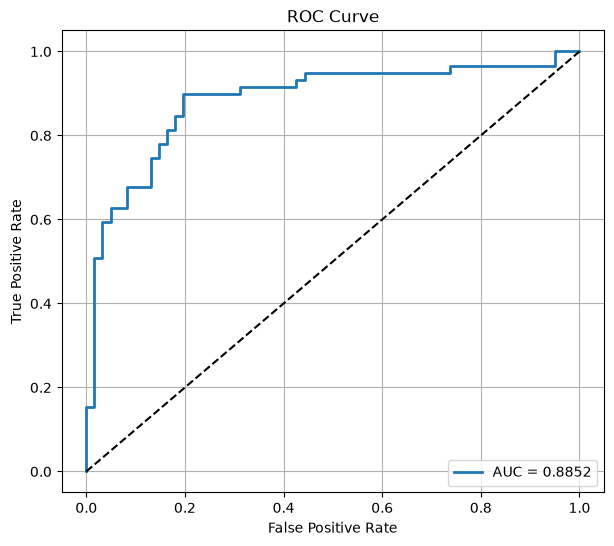

AUC Score : 0.8852


In [28]:
# ==========================================================
# STEP 27 : ROC Curve and AUC Score
# ==========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

model.eval()

true_labels = []
predicted_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        # Convert logits to probabilities
        probabilities = torch.softmax(outputs, dim=1)

        # Probability of TB class (class 1)
        tb_probability = probabilities[:, 1]

        predicted_probabilities.extend(tb_probability.cpu().numpy())
        true_labels.extend(labels.numpy())

# ------------------------------------------
# ROC Curve
# ------------------------------------------

fpr, tpr, thresholds = roc_curve(true_labels, predicted_probabilities)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr,
         linewidth=2,
         label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

print("="*60)
print(f"AUC Score : {roc_auc:.4f}")
print("="*60)

In [30]:
!pip install grad-cam

     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     - -------------------------------------- 0.3/7.8 MB ? eta -:--:--
     -- ------------------------------------- 0.5/7.8 MB 1.1 MB/s eta 0:00:07
     ---- ----------------------------------- 0.8/7.8 MB 892.1 kB/s eta 0:00:08
     ----- ---------------------------------- 1.0/7.8 MB 1.0 MB/s eta 0:00:07
     -------- ------------------------------- 1.6/7.8 MB 1.3 MB/s eta 0:00:05
     ---------- ----------------------------- 2.1/7.8 MB 1.5 MB/s eta 0:00:04
     ------------- -------------------------- 2.6/7.8 MB 1.7 MB/s eta 0:00:04
     ----------------- ---------------------- 3.4/7.8 MB 2.0 MB/s eta 0:00:03
     --------------------- ------------------ 4.2/7.8 MB 2.2 MB/s eta 0:00:02
     ------------------------- -------------- 5.0/7.8 MB 2.3 MB/s eta 0:00:02
     ---------------------------- ----------- 5.5/7.8 MB 2.4 MB/s eta 0:00:01
     


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
from pytorch_grad_cam import GradCAM

print("✅ Grad-CAM Installed Successfully!")

✅ Grad-CAM Installed Successfully!


In [32]:
print(model)

MaxxVit(
  (stem): Stem(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (norm1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (stages): Sequential(
    (0): MaxxVitStage(
      (blocks): Sequential(
        (0): MbConvBlock(
          (shortcut): Downsample2d(
            (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
            (expand): Conv2d(64, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          )
          (pre_norm): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (down): Identity()
          (conv1_1x1): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bia

In [33]:
for name, module in model.named_modules():
    print(name)


stem
stem.conv1
stem.norm1
stem.norm1.drop
stem.norm1.act
stem.conv2
stages
stages.0
stages.0.blocks
stages.0.blocks.0
stages.0.blocks.0.shortcut
stages.0.blocks.0.shortcut.pool
stages.0.blocks.0.shortcut.expand
stages.0.blocks.0.pre_norm
stages.0.blocks.0.pre_norm.drop
stages.0.blocks.0.pre_norm.act
stages.0.blocks.0.down
stages.0.blocks.0.conv1_1x1
stages.0.blocks.0.norm1
stages.0.blocks.0.norm1.drop
stages.0.blocks.0.norm1.act
stages.0.blocks.0.conv2_kxk
stages.0.blocks.0.se_early
stages.0.blocks.0.se_early.fc1
stages.0.blocks.0.se_early.bn
stages.0.blocks.0.se_early.act
stages.0.blocks.0.se_early.fc2
stages.0.blocks.0.se_early.gate
stages.0.blocks.0.norm2
stages.0.blocks.0.norm2.drop
stages.0.blocks.0.norm2.act
stages.0.blocks.0.conv3_1x1
stages.0.blocks.0.drop_path
stages.0.blocks.1
stages.0.blocks.1.shortcut
stages.0.blocks.1.pre_norm
stages.0.blocks.1.pre_norm.drop
stages.0.blocks.1.pre_norm.act
stages.0.blocks.1.down
stages.0.blocks.1.conv1_1x1
stages.0.blocks.1.norm1
stages.0

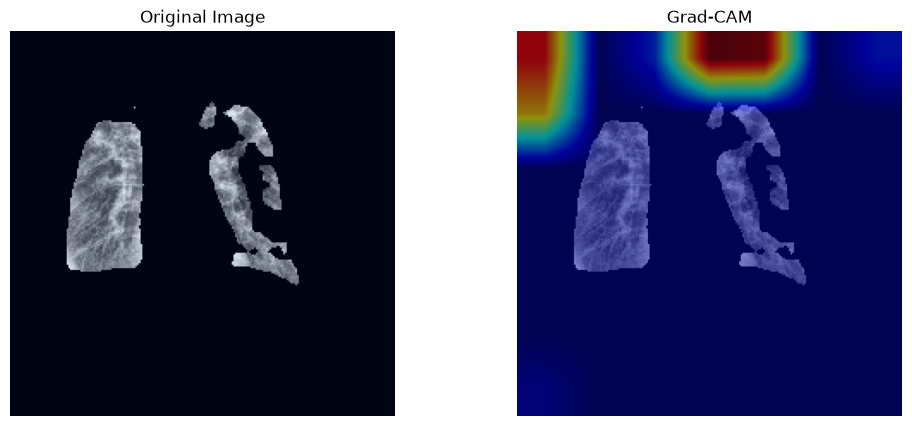

Prediction : TB
Actual     : TB


In [34]:
# ==========================================================
# STEP 28 : Grad-CAM Visualization
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# ----------------------------
# Target Layer
# ----------------------------

target_layers = [model.stages[3].blocks[1].norm2]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

# ----------------------------
# Take one image from test set
# ----------------------------

images, labels = next(iter(test_loader))

input_tensor = images[0].unsqueeze(0).to(device)

# ----------------------------
# Prediction
# ----------------------------

model.eval()

with torch.no_grad():

    outputs = model(input_tensor)

    prediction = torch.argmax(outputs, dim=1).item()

# ----------------------------
# Grad-CAM
# ----------------------------

grayscale_cam = cam(input_tensor=input_tensor)

grayscale_cam = grayscale_cam[0]

# ----------------------------
# Convert image for visualization
# ----------------------------

image = images[0].permute(1,2,0).numpy()

image = image.astype(np.float32)

image = (image - image.min()) / (image.max() - image.min())

visualization = show_cam_on_image(
    image,
    grayscale_cam,
    use_rgb=True
)

# ----------------------------
# Display
# ----------------------------

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

classes = ["Normal","TB"]

print("="*60)
print("Prediction :", classes[prediction])
print("Actual     :", classes[labels[0].item()])
print("="*60)

In [37]:
# ==========================================================
# STEP 29 : Automated Diagnostic Report
# ==========================================================

from datetime import datetime

classes = ["Normal", "Tuberculosis"]

predicted_class = classes[prediction]
actual_class = classes[labels[0].item()]
confidence_percent = confidence

print("="*75)
print("               AUTOMATED TB DIAGNOSTIC REPORT")
print("="*75)

print(f"Report Date          : {datetime.now().strftime('%d-%m-%Y %H:%M:%S')}")
print(f"Patient ID           : Sample Test Image")
print(f"Deep Learning Model  : Enhanced CoAtNet")
print(f"Input Image Size     : 224 × 224")
print("-"*75)

print(f"Actual Class         : {actual_class}")
print(f"Predicted Class      : {predicted_class}")
print(f"Prediction Confidence: {confidence_percent:.2f}%")

print("-"*75)

if predicted_class == "Tuberculosis":

    print("Diagnosis")
    print("---------")
    print("Tuberculosis Detected")

    print("\nClinical Interpretation")
    print("-----------------------")
    print("• The model identified radiographic features")
    print("  suggestive of pulmonary Tuberculosis.")
    print("• Immediate clinical evaluation is recommended.")
    print("• Further laboratory confirmation such as")
    print("  Sputum Smear, GeneXpert or Culture")
    print("  should be performed.")

else:

    print("Diagnosis")
    print("---------")
    print("Normal Chest X-ray")

    print("\nClinical Interpretation")
    print("-----------------------")
    print("• No radiographic evidence of")
    print("  Tuberculosis was detected.")
    print("• Continue routine clinical")
    print("  evaluation if symptoms persist.")

print("\nExplainability")
print("--------------")
print("Grad-CAM heatmap generated to visualize")
print("the regions influencing the model prediction.")

print("\nClinical Note")
print("-------------")
print("This system is intended to assist radiologists")
print("and should not replace professional")
print("medical diagnosis.")

print("="*75)

               AUTOMATED TB DIAGNOSTIC REPORT
Report Date          : 20-07-2026 18:18:01
Patient ID           : Sample Test Image
Deep Learning Model  : Enhanced CoAtNet
Input Image Size     : 224 × 224
---------------------------------------------------------------------------
Actual Class         : Tuberculosis
Predicted Class      : Tuberculosis
Prediction Confidence: 90.03%
---------------------------------------------------------------------------
Diagnosis
---------
Tuberculosis Detected

Clinical Interpretation
-----------------------
• The model identified radiographic features
  suggestive of pulmonary Tuberculosis.
• Immediate clinical evaluation is recommended.
• Further laboratory confirmation such as
  Sputum Smear, GeneXpert or Culture
  should be performed.

Explainability
--------------
Grad-CAM heatmap generated to visualize
the regions influencing the model prediction.

Clinical Note
-------------
This system is intended to assist radiologists
and should not replace p